# Reproducing the results

This notebook reproduces the main results from the thesis, *Argumentation-Based Coordination for Multi-Agent Reinforcement Learning in Overcooked*.

To do so, run the cells in order from the repository root.

This notebook reproduces the reported analyses from the saved runs in `results/`. It does not retrain the agents. See the [Training section of README.md](README.md#training) for the commands used to retrain each condition.

## Before you start

Use Python 3.10.

Install Overcooked-AI and the project dependencies:

```bash
python -m pip install git+https://github.com/HumanCompatibleAI/overcooked_ai.git
python -m pip install -r requirements.txt
```

The notebook uses the active kernel interpreter for all subprocesses. Select a
kernel from the environment in which these dependencies are installed.


Launch Jupyter from the repository root.

Importing the environment prints deprecation warnings from `pygame` and, in some environments, from the legacy `gym` package. They come from the dependencies, not from this repository, and do not affect the results.

`requirements.txt` pins `numpy<2.0` because Overcooked-AI calls `np.Inf`, which NumPy 2.0 removed.


## 1. Environment
The experiments use the Cramped Room layout, where two agents must coordinate in a small kitchen. Three onions are placed in the pot to cook a soup, which is then served for a reward of 20. Each episode lasts 400 steps, and one shared policy controls both agents.

The cell below shows the initial state.


pygame 2.6.1 (SDL 2.28.4, Python 3.10.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


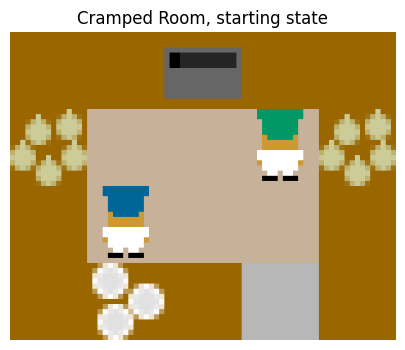

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pygame")

import sys

import matplotlib.pyplot as plt
import pygame
from overcooked_ai_py.visualization.state_visualizer import StateVisualizer

from af.env_wrapper import OvercookedAFEnv

env = OvercookedAFEnv(layout_name="cramped_room", horizon=400)
env.reset(seed=0)

surface = StateVisualizer().render_state(state=env.base_env.state, grid=env.mdp.terrain_mtx)
frame = pygame.surfarray.array3d(surface).swapaxes(0, 1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(frame)
ax.axis("off")
ax.set_title("Cramped Room, starting state")
plt.show()

**The Cramped Room starting state.** Two agents share one pot, two onion dispensers, a dish dispenser and one delivery point.

## 2. Argumentation framework

For each state, the framework creates and scores the available intentions, resolves conflicts between them and selects one intention for each agent.

The cell below applies the framework to the initial state using fixed weights of one, as in the ArgRL-Frozen condition. Only FetchOnion and Wait are available because no soup is ready to plate or deliver. Agents closer to an onion dispenser receive a higher FetchOnion score, while Wait has a score of zero.



In [2]:
import dataclasses

import numpy as np
import pandas as pd

from af.framework import (
    Intention,
    generate_arguments,
    generate_attacks_with_state,
    resolve_vaf,
)
from af.scoring import score_argument

profile = env._profile
weights = np.array([1.0, 1.0, 1.0])

# Reset the per-intention assignment counts so these scores match the first
# framework trigger after env.reset(), before either agent has been assigned.
state = dataclasses.replace(
    env._extract_af_state(),
    num_agents_assigned={intention: 0 for intention in Intention},
)

arguments = generate_arguments(state, num_agents=2)

for argument in arguments:
    argument.score = score_argument(argument, state, weights)

attacks = generate_attacks_with_state(arguments, state)
defeats = resolve_vaf(arguments, attacks)

The cell below lays the same arguments out as a table, one row per active argument, so the scores and planner distances behind the selection can be read directly. Wait keeps an agent where it is, so it has no target and no planner distance. Its steps to target entry is therefore empty rather than zero, which would wrongly read as a target already reached.

In [3]:
rows = []

for argument in arguments:
    # Wait has no target, so no planner distance is defined for it. The
    # entry is left missing rather than set to zero.
    if argument.intention is Intention.WAIT:
        steps_to_target = pd.NA
    else:
        steps_to_target = state.agent_steps_to_target[
            argument.agent_id
        ][argument.intention]

    rows.append(
        {
            "agent": argument.agent_id,
            "intention": argument.intention.name,
            "score": round(argument.score, 2),
            "steps to target": steps_to_target,
        }
    )

active_arguments = pd.DataFrame(rows)
active_arguments["steps to target"] = active_arguments[
    "steps to target"
].astype("Int64")

selected = ", ".join(
    f"agent {agent_id} {intention.name}"
    for agent_id, intention in profile.items()
)

print(f"{len(attacks)} attacks, of which {len(defeats)} succeed as defeats")
print(f"selected profile: {selected}")

active_arguments

4 attacks, of which 2 succeed as defeats
selected profile: agent 0 FETCH_ONION, agent 1 FETCH_ONION


,agent,intention,score,steps to target
0,0,FETCH_ONION,3.33,3
1,0,WAIT,0.00,<NA>
2,1,FETCH_ONION,3.50,2
3,1,WAIT,0.00,<NA>


## 3. Potential-based reward shaping
The potential function scores the selected intention profile. The shaping reward is based on the change in this value between consecutive states.

Both agents select FetchOnion in the initial state. This is allowed because the pot requires three onions. The coalition component is therefore zero, and only the individual component contributes.
The cell below calculates the full potential and each component separately using the same ablation settings used during training.



In [4]:
from af.reward_shaping import PotentialFunction

components = {
    "purpose": {"coalition", "load_ready"},
    "commit": {"individual", "load_ready"},
    "ready": {"individual", "coalition"},
}

rows = [
    {
        "component": "full potential",
        "phi": PotentialFunction().phi(state, profile),
    }
]

for name, ablated_components in components.items():
    component_value = PotentialFunction(
        ablate=ablated_components
    ).phi(state, profile)

    rows.append(
        {
            "component": name,
            "phi": component_value,
        }
    )

potential = pd.DataFrame(rows)
potential["phi"] = potential["phi"].round(3)

potential

,component,phi
0,full potential,0.75
1,purpose,0.75
2,commit,0.00
3,ready,0.00


## 4. Profile updates
The framework only runs when the environment resets, when an agent’s held object changes, or while an agent is assigned Wait.
The cell below takes 60 random steps and prints the profile whenever it changes. This shows how the selected intentions respond to changes in the environment state.

In [5]:
rng = np.random.default_rng(0)
shown = None

print("step  profile")
for step in range(60):
    env.step(rng.integers(0, 6, size=2))
    current = {i: v.name for i, v in env._profile.items()}
    if current != shown:
        print(f"{step:4d}  {current}")
        shown = current

print(f"\nframework triggers in these 60 steps: {env._af_trigger_count}")

step  profile
Computing MotionPlanner
   0  {0: 'FETCH_ONION', 1: 'FETCH_ONION'}
   9  {0: 'FETCH_ONION', 1: 'WAIT'}
  12  {0: 'FETCH_ONION', 1: 'FETCH_ONION'}
  56  {0: 'WAIT', 1: 'FETCH_ONION'}

framework triggers in these 60 steps: 9


## 5. Confirmatory results

This section reproduces the main results from 24 runs across four conditions and six seeds. For each seed, performance is measured as the mean soups delivered over the final 50 episodes.

The analysis runs four comparisons with Holm-corrected p-values and bootstrap confidence intervals.

The ArgRL-Full condition does not perform significantly better than the PPO baseline. The only significant difference is between ArgRL-Frozen and the PPO baseline, with the frozen agents delivering almost no soups.

In [6]:
!{sys.executable} analysis/confirmatory_analysis.py

Confirmatory analysis
Cramped Room, 1M steps, six seeds per condition, four parallel environments.
Performance is the mean over the final 50 logged episode outcomes, with the seed as the unit of analysis.



Runs
   Condition  Seed Final mean
PPO baseline     0     10.920
PPO baseline     1     10.800
PPO baseline     2     10.040
PPO baseline     3     10.640
PPO baseline     4     10.520
PPO baseline     5     11.760
ArgRL-Frozen     0      0.000
ArgRL-Frozen     1      0.000
ArgRL-Frozen     2      0.000
ArgRL-Frozen     3      0.000
ArgRL-Frozen     4      0.020
ArgRL-Frozen     5      0.040
  ArgRL-Full     0     10.520
  ArgRL-Full     1     10.740
  ArgRL-Full     2     11.780
  ArgRL-Full     3     10.760
  ArgRL-Full     4     11.720
  ArgRL-Full     5     10.600
   ArgRL-Obs     0     11.860
   ArgRL-Obs     1     11.680
   ArgRL-Obs     2     10.840
   ArgRL-Obs     3     11.700
   ArgRL-Obs     4     10.920
   ArgRL-Obs     5     10.820

Final performance
   Condition  Seeds   Mean    SD
PPO baseline      6 10.780 0.568
ArgRL-Frozen      6  0.010 0.017
  ArgRL-Full      6 11.020 0.573
   ArgRL-Obs      6 11.303 0.491

Pairwise tests, Mann-Whitney U, two-sided
Holm-Bonferroni co

Test                   Comparison      t          p Cohen's d Magnitude
  T1   ArgRL-Full vs PPO baseline -0.729 4.8297e-01    +0.421     small
  T2    ArgRL-Obs vs PPO baseline -1.707 1.1926e-01    +0.986     large
  T3      ArgRL-Full vs ArgRL-Obs  0.920 3.7964e-01    -0.531    medium
  T4 ArgRL-Frozen vs PPO baseline 46.395 8.5880e-08   -26.786     large

Conclusions
A comparison counts as positive when the Holm-corrected p is below 0.05 and the BCa interval excludes zero.
Test                   Comparison         Verdict
  T1   ArgRL-Full vs PPO baseline not significant
  T2    ArgRL-Obs vs PPO baseline not significant
  T3      ArgRL-Full vs ArgRL-Obs not significant
  T4 ArgRL-Frozen vs PPO baseline     significant



## 6. Reproducibility check

This check runs each condition twice using the same seeds and fixed actions. It then confirms that both runs produce identical reward sequences.

Because the actions are fixed, any difference would come from the environment, argumentation framework or reward shaping. The check prints a hash for each condition and passes only when all four match.


In [7]:
!{sys.executable} analysis/determinism_probe.py

Computing MotionPlanner


Computing MotionPlanner


Computing MotionPlanner


Computing MotionPlanner


Computing MotionPlanner


...

Computing MotionPlanner


Computing MotionPlanner


Computing MotionPlanner


Computing MotionPlanner


fatal: not a git repository (or any of the parent directories): .git
Determinism probe
Cramped Room, horizon 400, 1200 steps per run, two runs per condition.
Fixed action seed 12345 and reset seed 777, so a mismatch would come from the environment, the framework or the shaping rather than from policy sampling.
Code under test: unknown.

Reward streams
   Condition  Steps Identical across runs                                            Reward stream SHA-256
PPO baseline   1200                   yes c2b8c20a906cc836c607d790be9502f40c69c713c4e66187fe43d5fe25b99021
  ArgRL-Full   1200                   yes 515d5eece52b81cd26cae716fbbba46442699bccd0d52d273c3f8e5a0a9a5702
   ArgRL-Obs   1200                   yes c2b8c20a906cc836c607d790be9502f40c69c713c4e66187fe43d5fe25b99021
ArgRL-Frozen   1200                   yes 515d5eece52b81cd26cae716fbbba46442699bccd0d52d273c3f8e5a0a9a5702

Combined SHA-256 over the four digests: 0ed30e22acce9d6957f916cac8299861825717e0c6dc18a3426481331a3e260a
PASS,

## 7. Exploratory results

These analyses are reported as exploratory results.

The first tests the intention bias mechanism, which updates intention weights based on whether intentions are completed. The second tests ArgRL-Full with the intention profile removed from the observation.

Both perform similarly to the baseline.

In [8]:
!{sys.executable} exploratory/bandit_analysis.py
!{sys.executable} exploratory/shaping_only_analysis.py

Exploratory intention bias experiment
Cramped Room, 1M steps, six seeds. Performance is the mean over the final 50 logged episode outcomes.



Intention bias experiment runs
 Seed Final mean
    0     10.540
    1     10.780
    2     10.320
    3     11.880
    4     10.540
    5     11.000



Final performance
                   Condition   Mean    SD
Intention bias (exploratory) 10.843 0.559
                  ArgRL-Full 11.020 0.573
                PPO baseline 10.780 0.568

Mean differences
BCa intervals summarise the seed-level mean differences.
                                     Comparison Difference      BCa 95% CI
  Intention bias (exploratory) minus ArgRL-Full     -0.177 [-0.718, 0.430]
Intention bias (exploratory) minus PPO baseline     +0.063 [-0.477, 0.673]



ArgRL-Shape condition
ArgRL-Shape uses reward shaping but hides the intention profile from the policy observation, so the reward-shaping channel is active and the observation channel is disabled.
Cramped Room, 1M steps, six seeds. Performance is the mean over the final 50 logged episode outcomes, with the seed as the unit of analysis.

Final performance
                Condition   Mean    SD
             PPO baseline 10.780 0.568
             ArgRL-Frozen  0.010 0.017
                ArgRL-Obs 11.303 0.491
               ArgRL-Full 11.020 0.573
ArgRL-Shape (exploratory) 11.000 0.447

ArgRL-Shape comparisons
BCa intervals summarise the seed-level mean differences.
   Reference Difference      BCa 95% CI
PPO baseline     +0.220 [-0.303, 0.750]
   ArgRL-Obs     -0.303 [-0.743, 0.250]
  ArgRL-Full     -0.020 [-0.553, 0.497]

Learning dynamics
Normalised area under the training curve, higher is better, and the step at which the smoothed curve first reaches 0.8 of that seed's final mean, low